In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
import seaborn as sns

In [2]:
RESULTS_DF = "../data/results.parquet"
MFPQC_RESULTS_DF = "../data/mfpqc_results.parquet"

In [3]:
# Load mfpqc results
mfpqc_df = pd.read_parquet(MFPQC_RESULTS_DF)

# Rename columns
mfpqc_df = mfpqc_df.rename(
    columns={
        "Number of Qubits": "n_qubits",
        "Partitioner": "partitioner",
        "Num QPUs": "num_qpus",
        "Time taken (s)": "mfpqc_partition_exec_time_s",
        "Entanglement cost": "mfpqc_output_ebit_count",
    }
)

# Map benchmark names
FIGURE_MAP = {
    26: "disqco.mfpqc.cp_scaling.f0p3",
    27: "disqco.mfpqc.cp_scaling.f0p5",
    28: "disqco.mfpqc.cp_scaling.f0p7",
    29: "disqco.mfpqc.cp_scaling.f0p9",
    30: "disqco.mfpqc.cp_large",
    31: "disqco.mfpqc.qft",
    32: "disqco.mfpqc.qaoa",
    33: "disqco.mfpqc.qv",
}
mfpqc_df["benchmark"] = mfpqc_df["Figure"].map(FIGURE_MAP)

# Drop additional columns
mfpqc_df = mfpqc_df.drop(columns=["Figure", "Partitioner_raw"], errors="ignore")

# Fill missing num_qpus with 2
mfpqc_df["num_qpus"] = mfpqc_df["num_qpus"].fillna(2).astype(int)

# Map partitioner names to match ours
PARTITIONER_MAP = {
    "MLFM-R": "mlfm-r",
    "Pytket P": "pytket-dqc-p",
    "Pytket PE": "pytket-dqc-pe",
    "Pytket ESD": "pytket-dqc-esd",
    "FGP": "fgp",
    "FGP-rOEE": "fgp-roee",
}
mfpqc_df["partitioner"] = mfpqc_df["partitioner"].replace(PARTITIONER_MAP)

In [4]:
# Load our results
ours_df = pd.read_parquet(RESULTS_DF)

# Drop linear-4 and grid network topologies
ours_df = ours_df[
    ~((ours_df["network_topology"] == "linear") & (ours_df["num_qpus"] == 4))
]
ours_df = ours_df[
    ~((ours_df["network_topology"] == "mesh") & (ours_df["num_qpus"] == 4))
]

In [5]:
# Group by benchmark, partitioner, num_qpus, and n_qubits, taking the mean of numeric result columns
group_cols = ["benchmark", "partitioner", "num_qpus", "n_qubits"]
agg_map = {
    col: (
        "mean"
        if (col.startswith("input_") or col.startswith("output_"))
        and pd.api.types.is_numeric_dtype(ours_df[col])
        else "first"
    )
    for col in ours_df.columns
    if col != "status"
}
# Do the grouping separately for those that are not qasmbench, since the circuits with the same n_qubits are different circuits themselves, not instances of the same
mask_qasm = ours_df["benchmark"].str.contains("qasmbench", na=False)
qasm_df = ours_df[mask_qasm]
other_df = ours_df[~mask_qasm]

other_grouped = (
    other_df.groupby(group_cols, as_index=False)
    .agg(agg_map)
    .sort_values(by=group_cols)
    .reset_index(drop=True)
)
# Convert status to counts of each status per group
status_counts = (
    other_df.groupby(group_cols + ["status"]).size().unstack(fill_value=0).reset_index()
)
status_counts.columns = [
    col
    if col in group_cols
    else f"status_count_{str(col).replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')}"
    for col in status_counts.columns
]
other_grouped = other_grouped.merge(status_counts, on=group_cols, how="left")
# Finally, concat the grouped df with the ungrouped qasm_df
ours_df = (
    pd.concat([other_grouped, qasm_df], ignore_index=True)
    .sort_values(by=group_cols)
    .reset_index(drop=True)
)

In [6]:
# Rename columns to match mfpqc_df
ours_df = ours_df.rename(
    columns={
        "partition_exec_time_s": "ours_partition_exec_time_s",
        # "output_ebit_count": "ours_output_ebit_count",
        "distribution_cost": "ours_output_ebit_count",
    }
)
# Select only relevant columns for comparison
ours_df = ours_df[
    [
        "benchmark",
        "n_qubits",
        "num_qpus",
        "partitioner",
        "ours_partition_exec_time_s",
        "ours_output_ebit_count",
    ]
]

In [7]:
# Merge our results with mfpqc results
results_df = pd.merge(
    ours_df,
    mfpqc_df,
    on=["benchmark", "n_qubits", "num_qpus", "partitioner"],
    how="left",
)
# Drop rows where mfpqc_output_ebit_count is NaN, for those experiments with n_qubits where we have results but mfpqc doesn't
results_df = results_df.dropna(subset=["mfpqc_output_ebit_count"])

In [8]:
# Map partitioner names for plotting and sort them
PARTITIONER_LABEL_MAP = {
    "fgp": "FGP",
    "fgp-roee": "FGP-rOEE",
    "mlfm-r": "MLFM-R",
    "pytket-dqc-p": "Pytket P",
    "pytket-dqc-pe": "Pytket PE",
    "pytket-dqc-esd": "Pytket ESD",
}
all_partitioners = sorted(results_df["partitioner"].dropna().unique())
results_df["partitioner"] = (
    results_df["partitioner"]
    .map(PARTITIONER_LABEL_MAP)
    .fillna(results_df["partitioner"])
)
PARTITIONER_LABELS = [PARTITIONER_LABEL_MAP.get(p, p) for p in all_partitioners]

In [9]:
# Group benchmark names to group cp_scaling under "cp"
df_filtered = results_df.dropna(
    subset=["mfpqc_output_ebit_count", "ours_output_ebit_count"]
).copy()
df_filtered["benchmark"] = df_filtered["benchmark"].apply(
    lambda b: (
        "cp"
        if "cp_scaling" in str(b)
        else (str(b).split(".")[-1] if "." in str(b) else str(b))
    )
)

# Identify unique consolidated benchmarks, skipping any remaining qasmbench data
benchmarks = [b for b in df_filtered["benchmark"].unique() if "qasmbench" not in b]
num_benchmarks = len(benchmarks)

In [10]:
# Plotting configurations
PARTITIONER_PALETTE = {
    "FGP": "#E69F00",
    "FGP-rOEE": "#D55E00",
    "MLFM-R": "#009E73",
    "Pytket P": "#CC79A7",
    "Pytket PE": "#56B4E9",
    "Pytket ESD": "#8172B3",
}
TOPOLOGY_MARKER_MAP = {
    2: "o",
    4: "s",
}
plt.style.use(["science", "ieee", "grid"])
matplotlib.rcParams.update(
    {
        "font.family": "serif",
        "text.usetex": True,
    }
)

COLUMN_WIDTH = 3
BETWEEN_COLUMN_SPACING = 0.14
ASPECT_RATIO = 1 / 1
SCALE = 1.0
FIGURE_WIDTH = COLUMN_WIDTH * SCALE
FIGURE_HEIGHT = FIGURE_WIDTH * ASPECT_RATIO

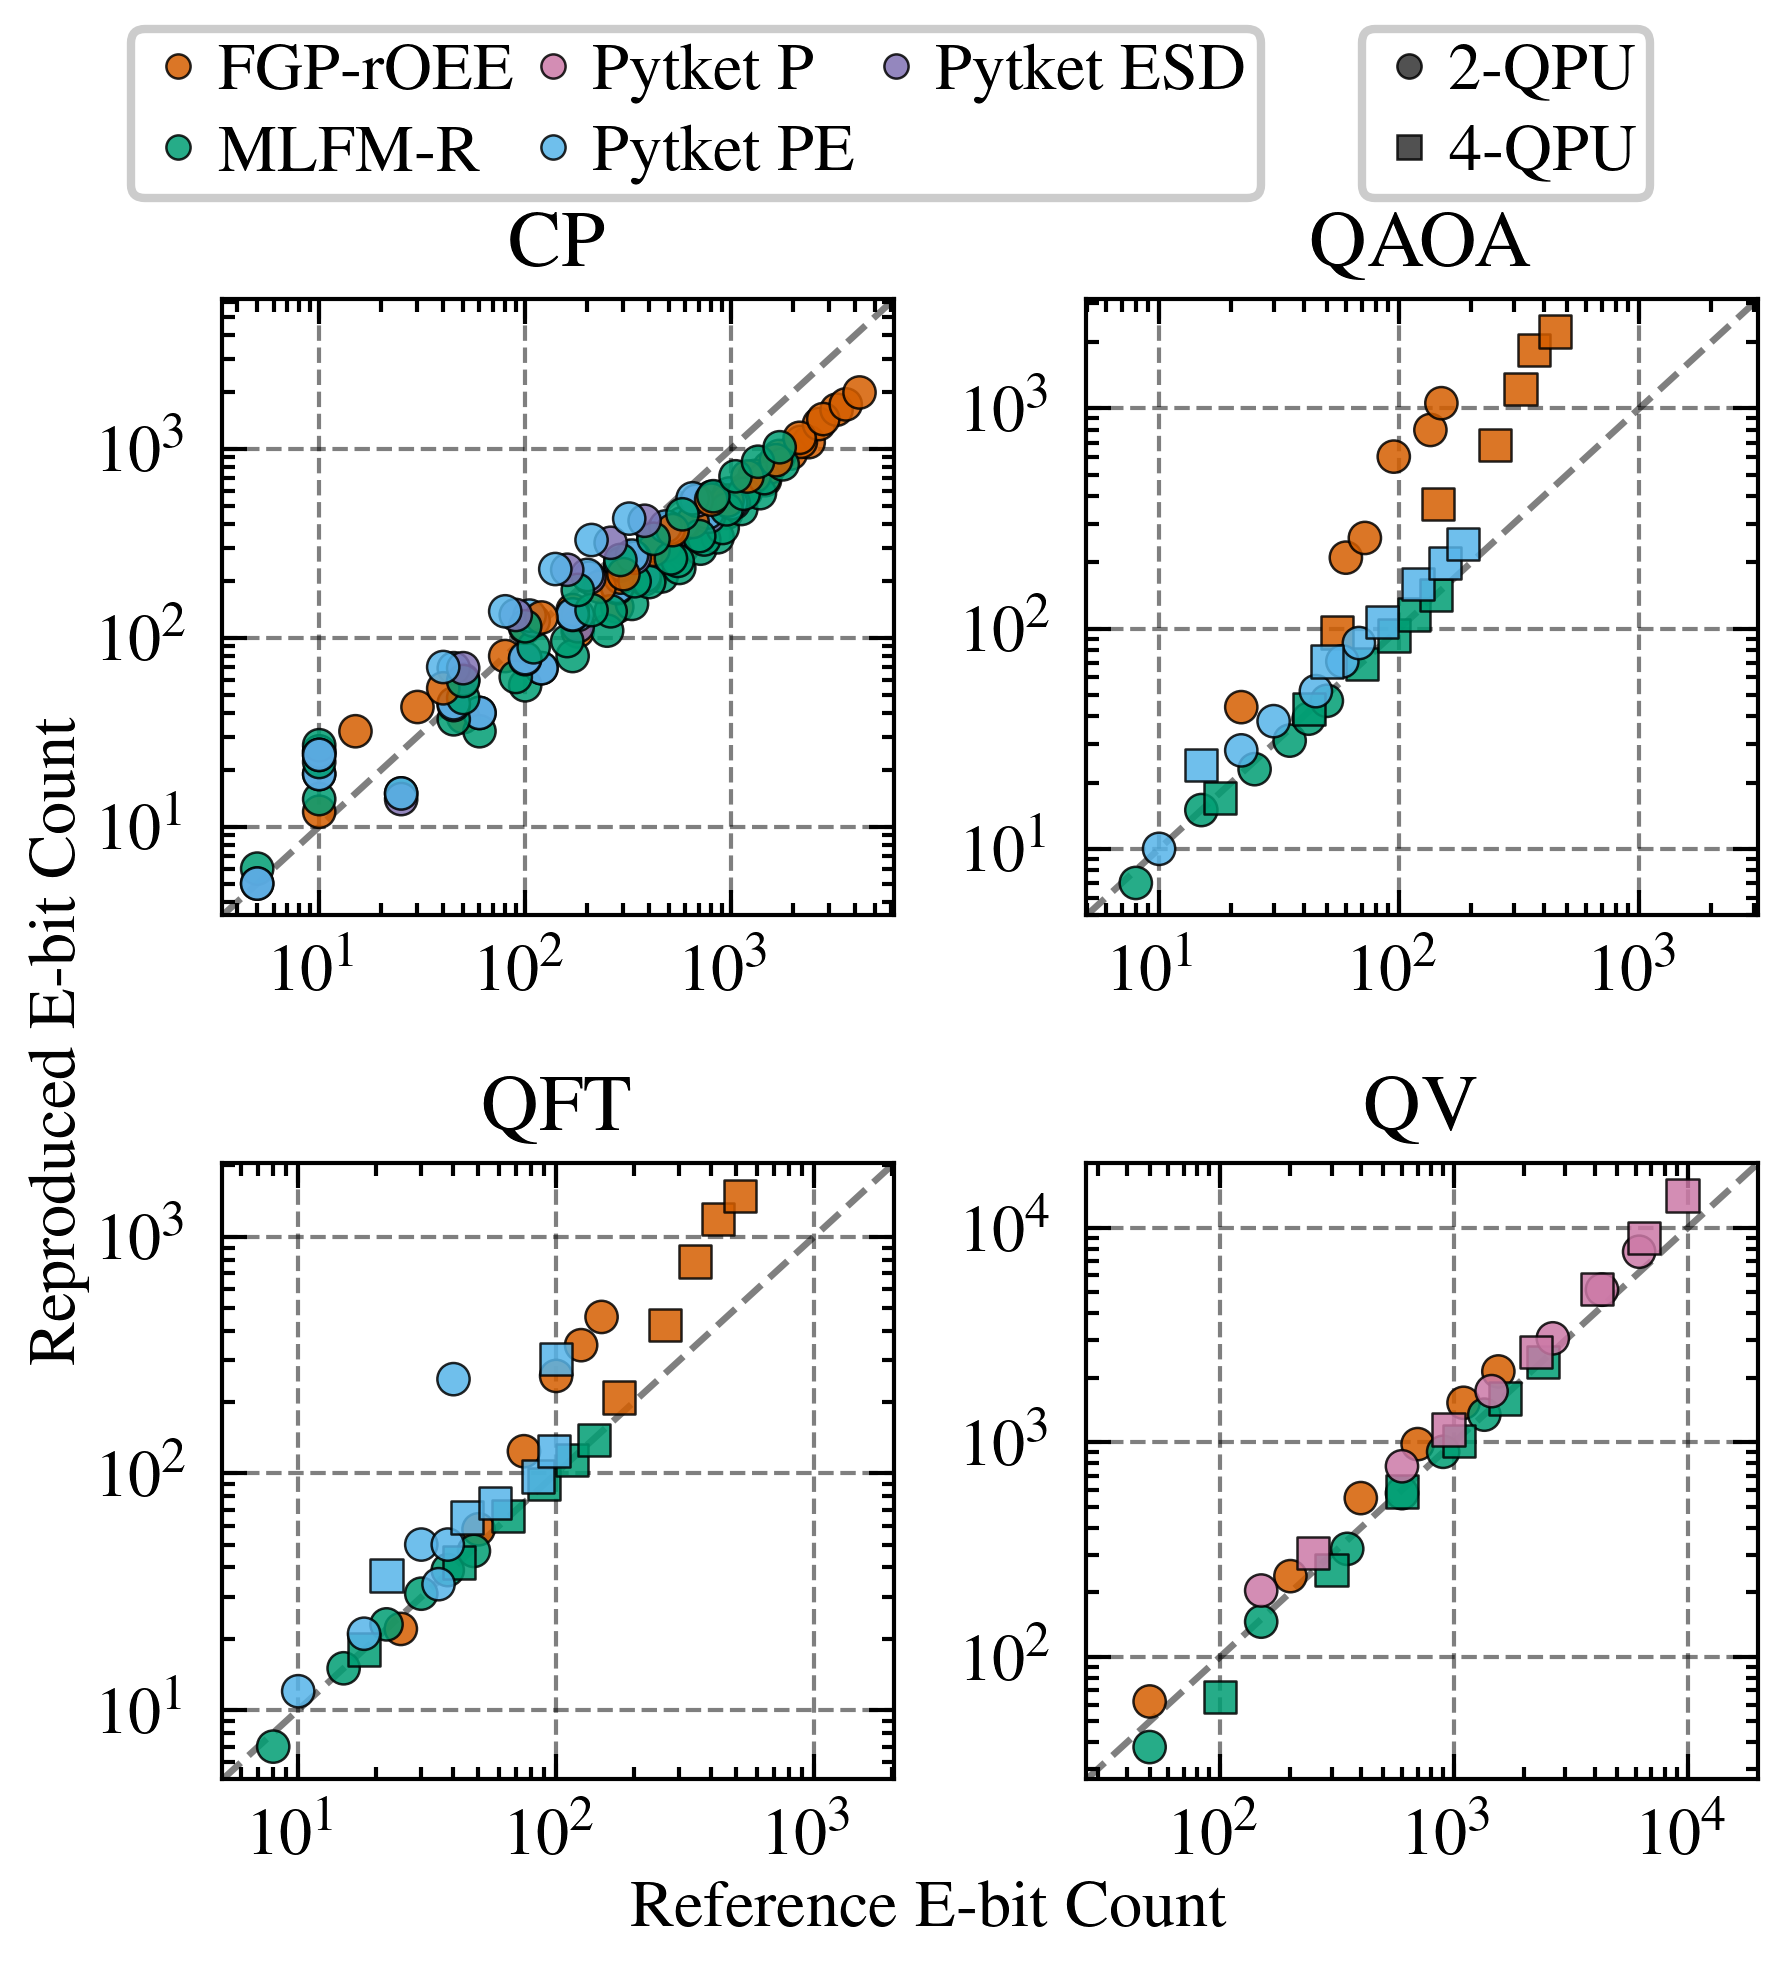

In [11]:
# Plotting
fig, axes = plt.subplots(
    int(num_benchmarks / 2),
    int(num_benchmarks / 2),
    figsize=(FIGURE_WIDTH, FIGURE_HEIGHT),
    sharey=False,
)

for i, benchmark in enumerate(benchmarks):
    ax = axes[i // 2, i % 2]
    df_bench = df_filtered[df_filtered["benchmark"] == benchmark]

    # Plot scatter points
    sns.scatterplot(
        data=df_bench,
        x="mfpqc_output_ebit_count",
        y="ours_output_ebit_count",
        hue="partitioner",
        style="num_qpus",
        palette=PARTITIONER_PALETTE,
        hue_order=PARTITIONER_LABELS,
        markers=TOPOLOGY_MARKER_MAP,
        s=15,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
        legend="full",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    # Calculate tight uniform limits
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    abs_min = min(x_min, y_min) * 0.95
    abs_max = max(x_max, y_max) * 1.05

    ax.set_xlim(abs_min, abs_max)
    ax.set_ylim(abs_min, abs_max)

    ax.plot(
        [abs_min, abs_max],
        [abs_min, abs_max],
        linestyle="--",
        color="#7f7f7f",
        linewidth=0.8,
        zorder=0,
    )

    ax.set_title(benchmark.upper(), pad=4)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both")

# Create legends
# Remove individual subplot legends and collect unique handles/labels
unique_items = {}
for ax_ in axes.flat:
    if ax_.get_legend():
        handles, labels = ax_.get_legend_handles_labels()
        for h, l in zip(handles, labels):
            if l not in unique_items:
                unique_items[l] = h
        ax_.get_legend().remove()

# Separate items (ignoring Seaborn's text-only header labels)
part_labels = [l for l in PARTITIONER_PALETTE.keys() if l in unique_items]
part_handles = [unique_items[l] for l in part_labels]

qpu_labels = sorted([l for l in unique_items.keys() if l.isdigit()], key=int)
qpu_handles = [unique_items[l] for l in qpu_labels]
# Add -QPU suffix to qpu_labels for clarity
qpu_labels = [f"{l}-QPU" for l in qpu_labels]

# Legend 1: Partitioning Method (Centered left above the figure)
leg_part = fig.legend(
    part_handles,
    part_labels,
    # title="Partitioning Method",
    loc="upper center",
    bbox_to_anchor=(0.37, 1.08),
    ncol=3,
    frameon=True,
    handletextpad=0.1,
    columnspacing=0.1,
    borderpad=0.2,
    labelspacing=0.3,
    handlelength=1.0,
    markerscale=0.75,
)

# Legend 2: Num. QPUs (Centered right above the figure)
leg_qpu = fig.legend(
    qpu_handles,
    qpu_labels,
    # title="Num. QPUs",
    loc="upper center",
    bbox_to_anchor=(0.82, 1.08),
    ncol=1,
    frameon=True,
    handletextpad=0.1,
    columnspacing=0.1,
    borderpad=0.2,
    labelspacing=0.3,
    handlelength=1.0,
    markerscale=0.75,
)

# Add shared axis labels
fig.text(0.5, 0.0, "Reference E-bit Count", ha="center", va="bottom")
fig.text(
    0.0, 0.5, "Reproduced E-bit Count", ha="left", va="center", rotation="vertical"
)

plt.tight_layout()
plt.savefig("figures/reference_comparison.pdf", bbox_inches="tight", dpi=300)